#### Imports

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet("../data/integrated/algeria_wildfire_dataset.parquet")
df["date"] = pd.to_datetime(df["date"])

RISK_LABELS  = {0: "LOW", 1: "MODERATE", 2: "HIGH"}
RISK_COLORS  = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
RISK_PALETTE = [RISK_COLORS[i] for i in sorted(RISK_COLORS)]

df["risk_label"] = df["next_day_risk_class"].map(RISK_LABELS)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Loaded: 156,480 rows × 43 columns
Date range: 2015-06-01 → 2025-10-30


#### Weather distributions

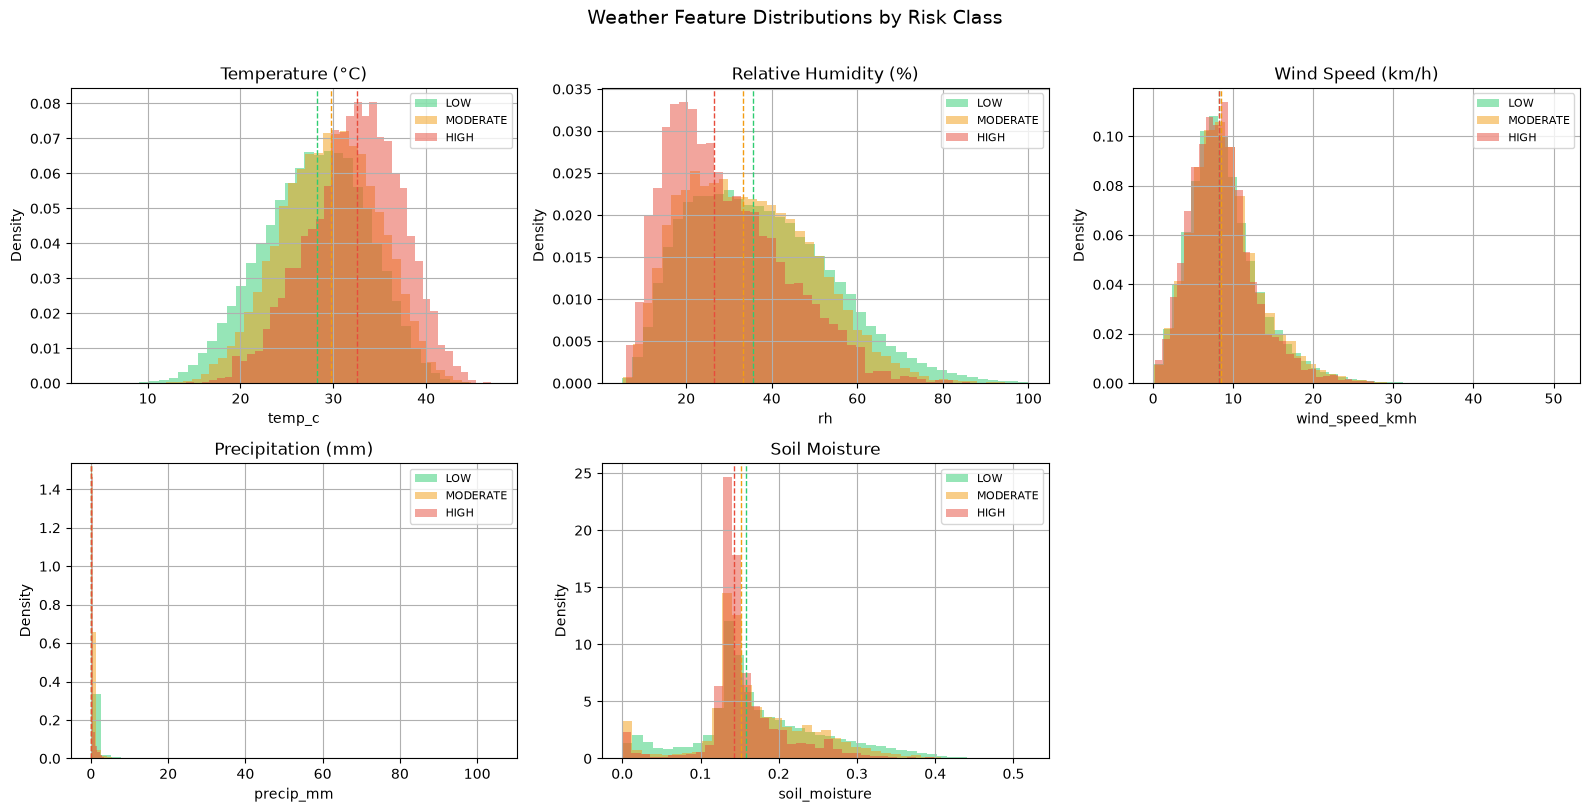


Median weather values by risk class:
                        temp_c     rh  wind_speed_kmh  precip_mm  soil_moisture
next_day_risk_class                                                            
0                    28.270000  35.66            8.25       0.09           0.16
1                    29.730000  33.34            8.51       0.02           0.15
2                    32.580002  26.49            8.20       0.01           0.14


In [2]:
weather_cols = {
    "temp_c":          "Temperature (°C)",
    "rh":              "Relative Humidity (%)",
    "wind_speed_kmh":  "Wind Speed (km/h)",
    "precip_mm":       "Precipitation (mm)",
    "soil_moisture":   "Soil Moisture",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(weather_cols.items()):
    ax = axes[i]
    for cls in [0, 1, 2]:
        subset = df[df["next_day_risk_class"] == cls][col].dropna()
        subset.hist(ax=ax, bins=40, alpha=0.5,
                    color=RISK_COLORS[cls], label=RISK_LABELS[cls],
                    density=True)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # Add median lines
    for cls in [0, 1, 2]:
        med = df[df["next_day_risk_class"] == cls][col].median()
        ax.axvline(med, color=RISK_COLORS[cls], linestyle="--", linewidth=1)

axes[-1].set_visible(False)
fig.suptitle("Weather Feature Distributions by Risk Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("outputs/02_weather_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary stats per class
print("\nMedian weather values by risk class:")
print(df.groupby("next_day_risk_class")[list(weather_cols.keys())].median().round(2).to_string())

#### FWI distributions

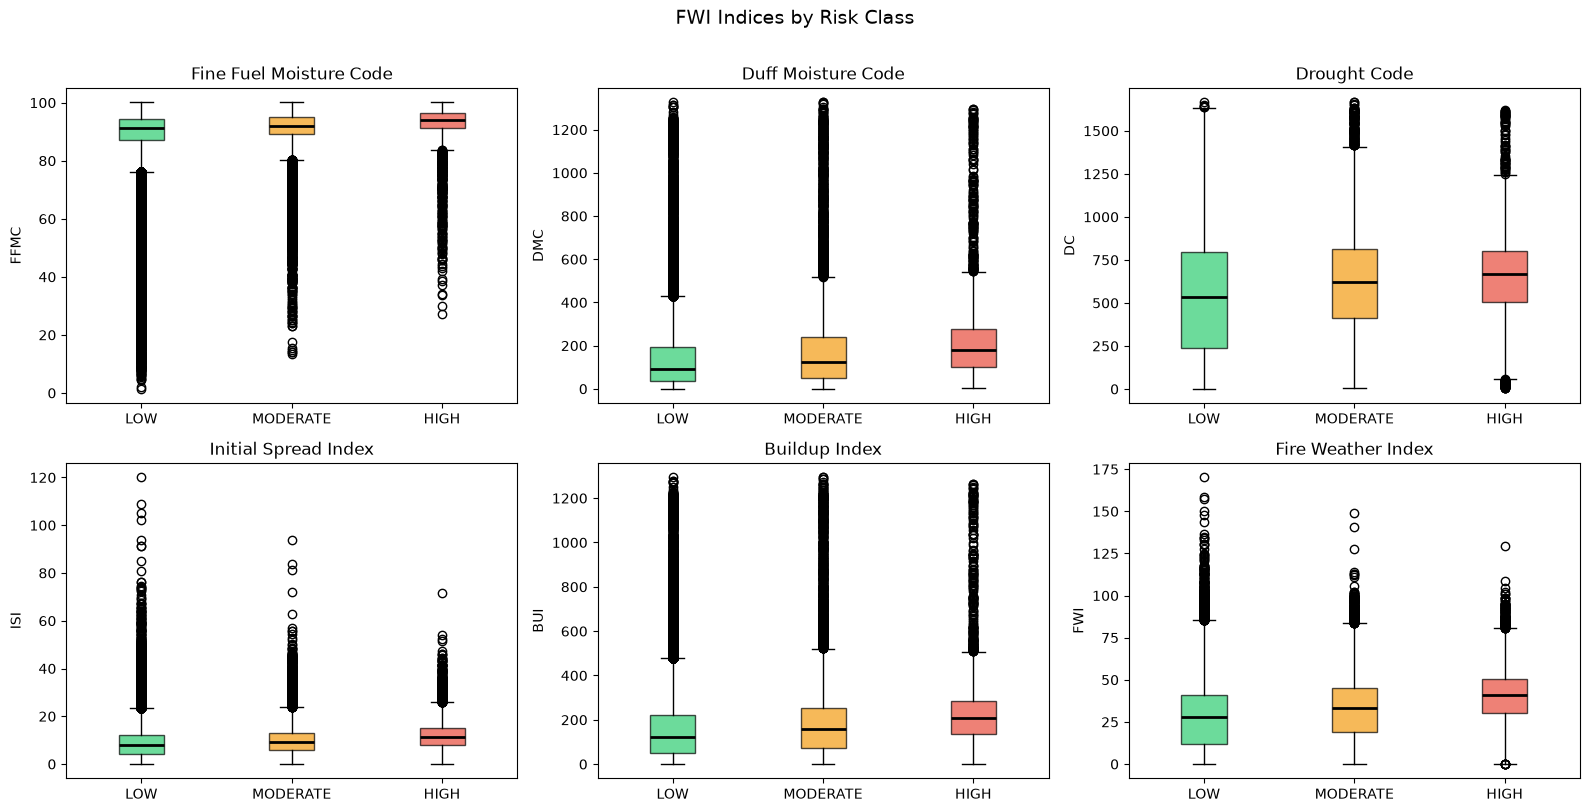


FWI median by risk class:
                     FFMC    DMC     DC   ISI    BUI   FWI
next_day_risk_class                                       
0                    91.3   92.9  535.9   8.0  121.7  28.2
1                    92.1  124.3  624.0   9.1  159.0  33.4
2                    94.0  180.5  668.5  11.3  206.0  41.0

FWI distribution:
  < 5  (Very Low):     21,543 rows (13.8%)
  5–11 (Low):          12,281 rows (7.8%)
  11–21 (Moderate):    21,334 rows (13.6%)
  21–33 (High):        32,947 rows (21.1%)
  33–50 (Very High):   47,280 rows (30.2%)
  >= 50 (Extreme):     21,095 rows (13.5%)


In [3]:
fwi_cols = {
    "FFMC": "Fine Fuel Moisture Code",
    "DMC":  "Duff Moisture Code",
    "DC":   "Drought Code",
    "ISI":  "Initial Spread Index",
    "BUI":  "Buildup Index",
    "FWI":  "Fire Weather Index",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(fwi_cols.items()):
    ax = axes[i]
    data = [df[df["next_day_risk_class"] == cls][col].dropna()
            for cls in [0, 1, 2]]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
    for patch, cls in zip(bp["boxes"], [0, 1, 2]):
        patch.set_facecolor(RISK_COLORS[cls])
        patch.set_alpha(0.7)
    ax.set_xticklabels([RISK_LABELS[i] for i in [0, 1, 2]])
    ax.set_title(label)
    ax.set_ylabel(col)

fig.suptitle("FWI Indices by Risk Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("outputs/02_fwi_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFWI median by risk class:")
print(df.groupby("next_day_risk_class")[list(fwi_cols.keys())].median().round(1).to_string())

# Flag: FWI thresholds for Algeria context
fwi = df["FWI"]
print(f"\nFWI distribution:")
print(f"  < 5  (Very Low):   {(fwi < 5).sum():>8,} rows ({100*(fwi<5).mean():.1f}%)")
print(f"  5–11 (Low):        {((fwi>=5)&(fwi<11)).sum():>8,} rows ({100*((fwi>=5)&(fwi<11)).mean():.1f}%)")
print(f"  11–21 (Moderate):  {((fwi>=11)&(fwi<21)).sum():>8,} rows ({100*((fwi>=11)&(fwi<21)).mean():.1f}%)")
print(f"  21–33 (High):      {((fwi>=21)&(fwi<33)).sum():>8,} rows ({100*((fwi>=21)&(fwi<33)).mean():.1f}%)")
print(f"  33–50 (Very High): {((fwi>=33)&(fwi<50)).sum():>8,} rows ({100*((fwi>=33)&(fwi<50)).mean():.1f}%)")
print(f"  >= 50 (Extreme):   {(fwi>=50).sum():>8,} rows ({100*(fwi>=50).mean():.1f}%)")

#### Vegetation Indices

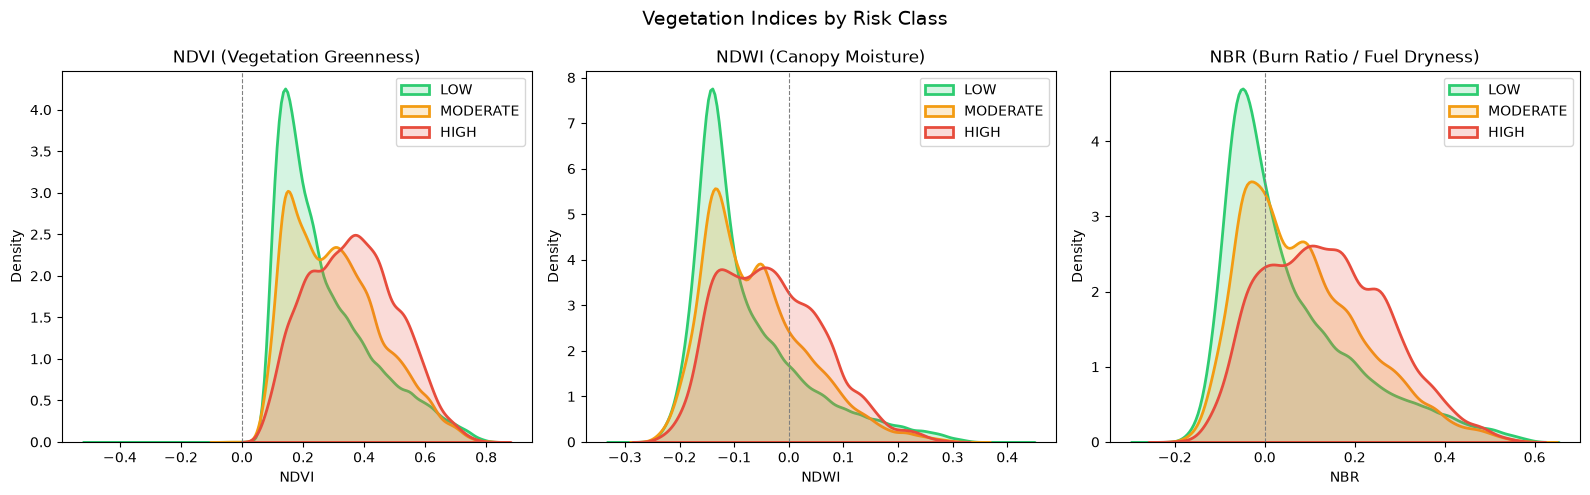


Vegetation index median by risk class:
                      NDVI   NDWI    NBR
next_day_risk_class                     
0                    0.224 -0.112  0.008
1                    0.289 -0.078  0.061
2                    0.358 -0.041  0.126


In [4]:
veg_cols = {
    "NDVI": "NDVI (Vegetation Greenness)",
    "NDWI": "NDWI (Canopy Moisture)",
    "NBR":  "NBR (Burn Ratio / Fuel Dryness)",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, label) in enumerate(veg_cols.items()):
    ax = axes[i]
    for cls in [0, 1, 2]:
        subset = df[df["next_day_risk_class"] == cls][col].dropna()
        sns.kdeplot(subset, ax=ax, color=RISK_COLORS[cls],
                    label=RISK_LABELS[cls], linewidth=2, fill=True, alpha=0.2)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")

fig.suptitle("Vegetation Indices by Risk Class", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/02_vegetation_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nVegetation index median by risk class:")
print(df.groupby("next_day_risk_class")[list(veg_cols.keys())].median().round(3).to_string())

#### Temporal patterns

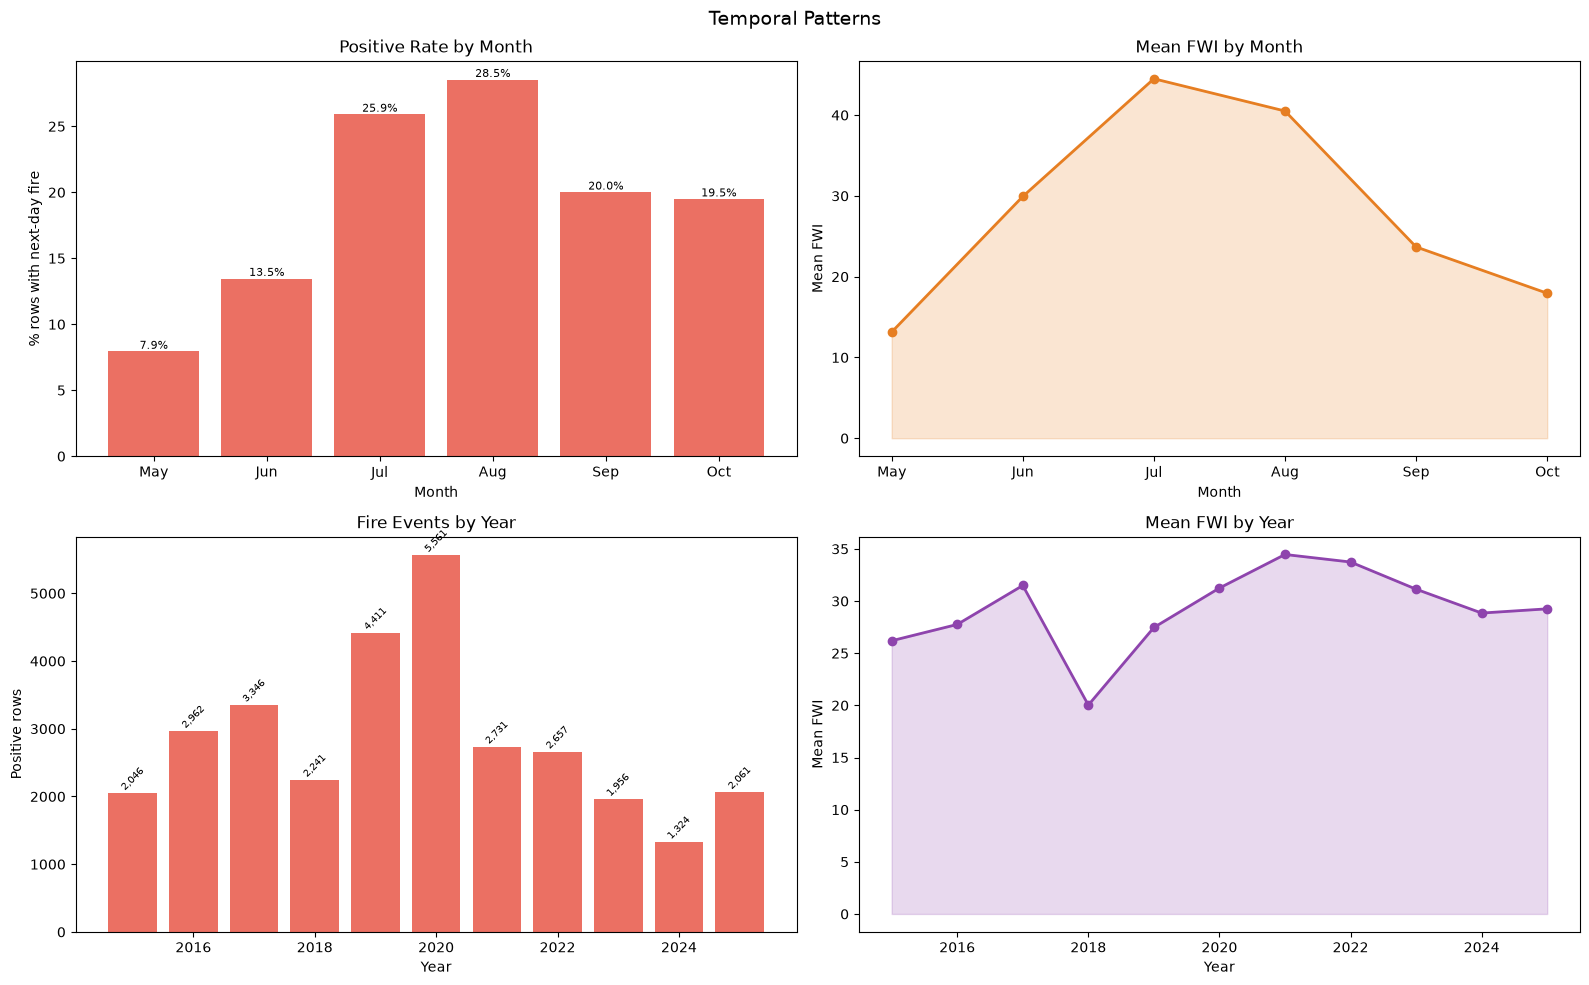


Fire season summary by month:
       total_rows  fire_rows  positive_rate  mean_FWI  mean_temp    mean_rh
month                                                                      
5           21249       1687            7.9      13.1  23.299999  43.500000
6           24144       3251           13.5      29.9  29.100000  34.700001
7           28818       7466           25.9      44.5  33.099998  28.700001
8           30090       8588           28.5      40.5  32.400002  31.299999
9           26123       5226           20.0      23.7  27.600000  41.200001
10          26056       5078           19.5      17.9  23.400000  43.200001


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Fire events by month
monthly_fires = df[df["next_day_risk_class"] > 0].groupby("month").size()
monthly_total = df.groupby("month").size()
monthly_rate  = (100 * monthly_fires / monthly_total).fillna(0)

axes[0, 0].bar(monthly_rate.index, monthly_rate.values, color="#e74c3c", alpha=0.8)
axes[0, 0].set_title("Positive Rate by Month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("% rows with next-day fire")
axes[0, 0].set_xticks(range(5, 11))
axes[0, 0].set_xticklabels(["May","Jun","Jul","Aug","Sep","Oct"])
for x, y in zip(monthly_rate.index, monthly_rate.values):
    axes[0, 0].text(x, y + 0.2, f"{y:.1f}%", ha="center", fontsize=8)

# Mean FWI by month
monthly_fwi = df.groupby("month")["FWI"].mean()
axes[0, 1].plot(monthly_fwi.index, monthly_fwi.values,
                marker="o", color="#e67e22", linewidth=2)
axes[0, 1].fill_between(monthly_fwi.index, monthly_fwi.values, alpha=0.2, color="#e67e22")
axes[0, 1].set_title("Mean FWI by Month")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Mean FWI")
axes[0, 1].set_xticks(range(5, 11))
axes[0, 1].set_xticklabels(["May","Jun","Jul","Aug","Sep","Oct"])

# Fire events by year
yearly_fires = df[df["next_day_risk_class"] > 0].groupby("year").size()
axes[1, 0].bar(yearly_fires.index, yearly_fires.values, color="#e74c3c", alpha=0.8)
axes[1, 0].set_title("Fire Events by Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Positive rows")
for x, y in zip(yearly_fires.index, yearly_fires.values):
    axes[1, 0].text(x, y + 50, f"{y:,}", ha="center", fontsize=7, rotation=45)

# Mean FWI by year
yearly_fwi = df.groupby("year")["FWI"].mean()
axes[1, 1].plot(yearly_fwi.index, yearly_fwi.values,
                marker="o", color="#8e44ad", linewidth=2)
axes[1, 1].fill_between(yearly_fwi.index, yearly_fwi.values, alpha=0.2, color="#8e44ad")
axes[1, 1].set_title("Mean FWI by Year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Mean FWI")

fig.suptitle("Temporal Patterns", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/02_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFire season summary by month:")
summary = pd.DataFrame({
    "total_rows":    monthly_total,
    "fire_rows":     monthly_fires,
    "positive_rate": monthly_rate.round(1),
    "mean_FWI":      df.groupby("month")["FWI"].mean().round(1),
    "mean_temp":     df.groupby("month")["temp_c"].mean().round(1),
    "mean_rh":       df.groupby("month")["rh"].mean().round(1),
})
print(summary.to_string())

#### Spatial patterns

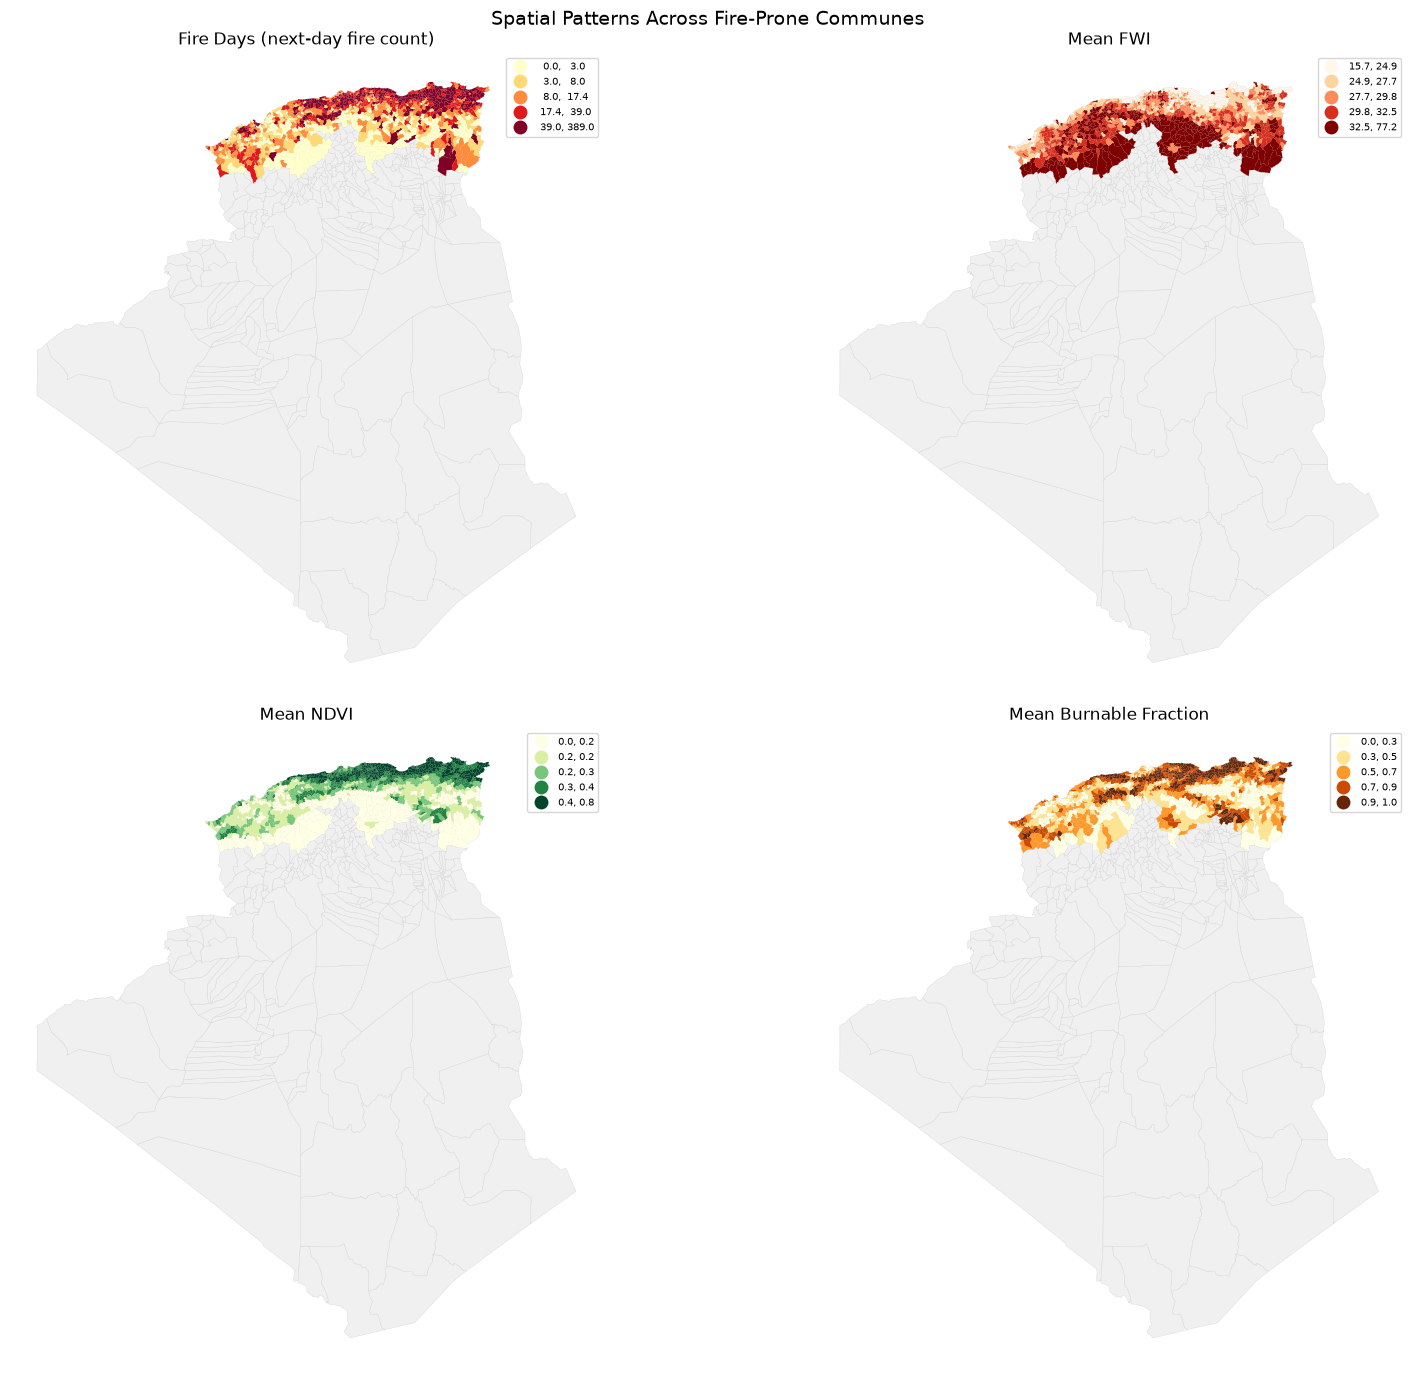

In [7]:
communes = gpd.read_file("../data/curated/boundaries/algeria_communes.gpkg")
communes = communes.rename(columns={
    "GID_2": "commune_id", "NAME_2": "commune_name",
    "GID_1": "wilaya_id",  "NAME_1": "wilaya_name"
})

# Aggregate key metrics per commune
commune_stats = df.groupby("commune_id").agg(
    fire_days        =("next_day_risk_class", lambda x: (x > 0).sum()),
    positive_rate    =("next_day_risk_class", lambda x: (x > 0).mean()),
    mean_FWI         =("FWI",       "mean"),
    mean_temp        =("temp_c",    "mean"),
    mean_NDVI        =("NDVI",      "mean"),
    mean_burnable    =("burnable_fraction", "mean"),
).reset_index()

communes_merged = communes.merge(commune_stats, on="commune_id", how="left")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

maps = [
    ("fire_days",     "Fire Days (next-day fire count)", "YlOrRd"),
    ("mean_FWI",      "Mean FWI",                        "OrRd"),
    ("mean_NDVI",     "Mean NDVI",                       "YlGn"),
    ("mean_burnable", "Mean Burnable Fraction",          "YlOrBr"),
]

for ax, (col, title, cmap) in zip(axes.flatten(), maps):
    # Background — all communes
    communes_merged.plot(ax=ax, color="#f0f0f0",
                         edgecolor="#cccccc", linewidth=0.2)
    # Data layer — only communes in dataset
    data = communes_merged[communes_merged[col].notna()]
    data.plot(column=col, ax=ax, cmap=cmap,
              legend=True, scheme="quantiles", k=5,
              legend_kwds={"fmt": "{:.1f}", "fontsize": 7})
    ax.set_title(title, fontsize=12)
    ax.axis("off")

fig.suptitle("Spatial Patterns Across Fire-Prone Communes", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/02_spatial_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

#### Feature relationships

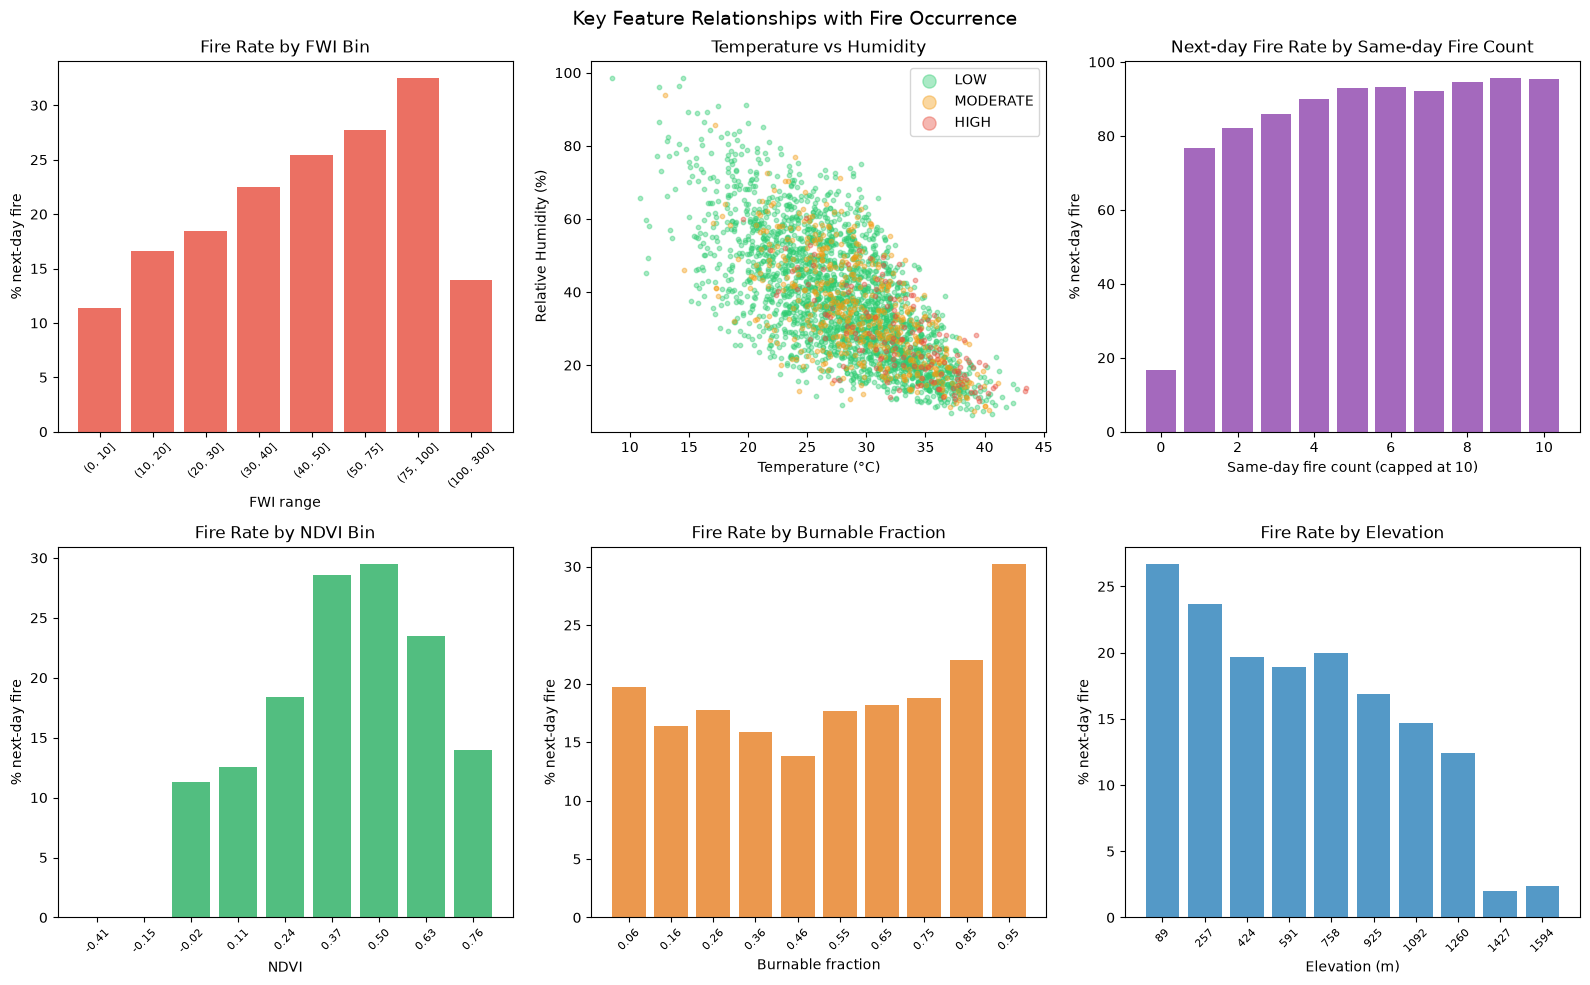

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# FWI vs fire occurrence
fwi_bins = pd.cut(df["FWI"], bins=[0,10,20,30,40,50,75,100,300])
fwi_fire = df.groupby(fwi_bins, observed=True)["next_day_risk_class"].apply(
    lambda x: (x > 0).mean() * 100
)
axes[0, 0].bar(range(len(fwi_fire)), fwi_fire.values, color="#e74c3c", alpha=0.8)
axes[0, 0].set_xticks(range(len(fwi_fire)))
axes[0, 0].set_xticklabels([str(b) for b in fwi_fire.index], rotation=45, fontsize=8)
axes[0, 0].set_title("Fire Rate by FWI Bin")
axes[0, 0].set_ylabel("% next-day fire")
axes[0, 0].set_xlabel("FWI range")

# Temp vs RH scatter colored by class (sample 3000 points)
sample = df.sample(min(3000, len(df)), random_state=42)
for cls in [0, 1, 2]:
    s = sample[sample["next_day_risk_class"] == cls]
    axes[0, 1].scatter(s["temp_c"], s["rh"],
                       c=RISK_COLORS[cls], label=RISK_LABELS[cls],
                       alpha=0.4, s=10)
axes[0, 1].set_title("Temperature vs Humidity")
axes[0, 1].set_xlabel("Temperature (°C)")
axes[0, 1].set_ylabel("Relative Humidity (%)")
axes[0, 1].legend(markerscale=3)

# Same-day fire_count vs next-day risk
df["fire_count_capped"] = df["fire_count"].clip(upper=10)
fc_fire = df.groupby("fire_count_capped")["next_day_risk_class"].apply(
    lambda x: (x > 0).mean() * 100
)
axes[0, 2].bar(fc_fire.index, fc_fire.values, color="#8e44ad", alpha=0.8)
axes[0, 2].set_title("Next-day Fire Rate by Same-day Fire Count")
axes[0, 2].set_xlabel("Same-day fire count (capped at 10)")
axes[0, 2].set_ylabel("% next-day fire")

# NDVI vs fire rate
ndvi_bins = pd.cut(df["NDVI"], bins=10)
ndvi_fire = df.groupby(ndvi_bins, observed=True)["next_day_risk_class"].apply(
    lambda x: (x > 0).mean() * 100
)
axes[1, 0].bar(range(len(ndvi_fire)), ndvi_fire.values, color="#27ae60", alpha=0.8)
axes[1, 0].set_xticks(range(len(ndvi_fire)))
axes[1, 0].set_xticklabels([f"{b.mid:.2f}" for b in ndvi_fire.index],
                             rotation=45, fontsize=8)
axes[1, 0].set_title("Fire Rate by NDVI Bin")
axes[1, 0].set_ylabel("% next-day fire")
axes[1, 0].set_xlabel("NDVI")

# Burnable fraction vs fire rate
burn_bins = pd.cut(df["burnable_fraction"], bins=10)
burn_fire = df.groupby(burn_bins, observed=True)["next_day_risk_class"].apply(
    lambda x: (x > 0).mean() * 100
)
axes[1, 1].bar(range(len(burn_fire)), burn_fire.values, color="#e67e22", alpha=0.8)
axes[1, 1].set_xticks(range(len(burn_fire)))
axes[1, 1].set_xticklabels([f"{b.mid:.2f}" for b in burn_fire.index],
                             rotation=45, fontsize=8)
axes[1, 1].set_title("Fire Rate by Burnable Fraction")
axes[1, 1].set_ylabel("% next-day fire")
axes[1, 1].set_xlabel("Burnable fraction")

# Elevation vs fire rate
elev_bins = pd.cut(df["elevation_mean_m"].dropna(), bins=10)
elev_fire = df.dropna(subset=["elevation_mean_m"]).groupby(
    elev_bins, observed=True
)["next_day_risk_class"].apply(lambda x: (x > 0).mean() * 100)
axes[1, 2].bar(range(len(elev_fire)), elev_fire.values, color="#2980b9", alpha=0.8)
axes[1, 2].set_xticks(range(len(elev_fire)))
axes[1, 2].set_xticklabels([f"{b.mid:.0f}" for b in elev_fire.index],
                             rotation=45, fontsize=8)
axes[1, 2].set_title("Fire Rate by Elevation")
axes[1, 2].set_ylabel("% next-day fire")
axes[1, 2].set_xlabel("Elevation (m)")

fig.suptitle("Key Feature Relationships with Fire Occurrence", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/02_feature_relationships.png", dpi=150, bbox_inches="tight")
plt.show()

#### Correlation matrix

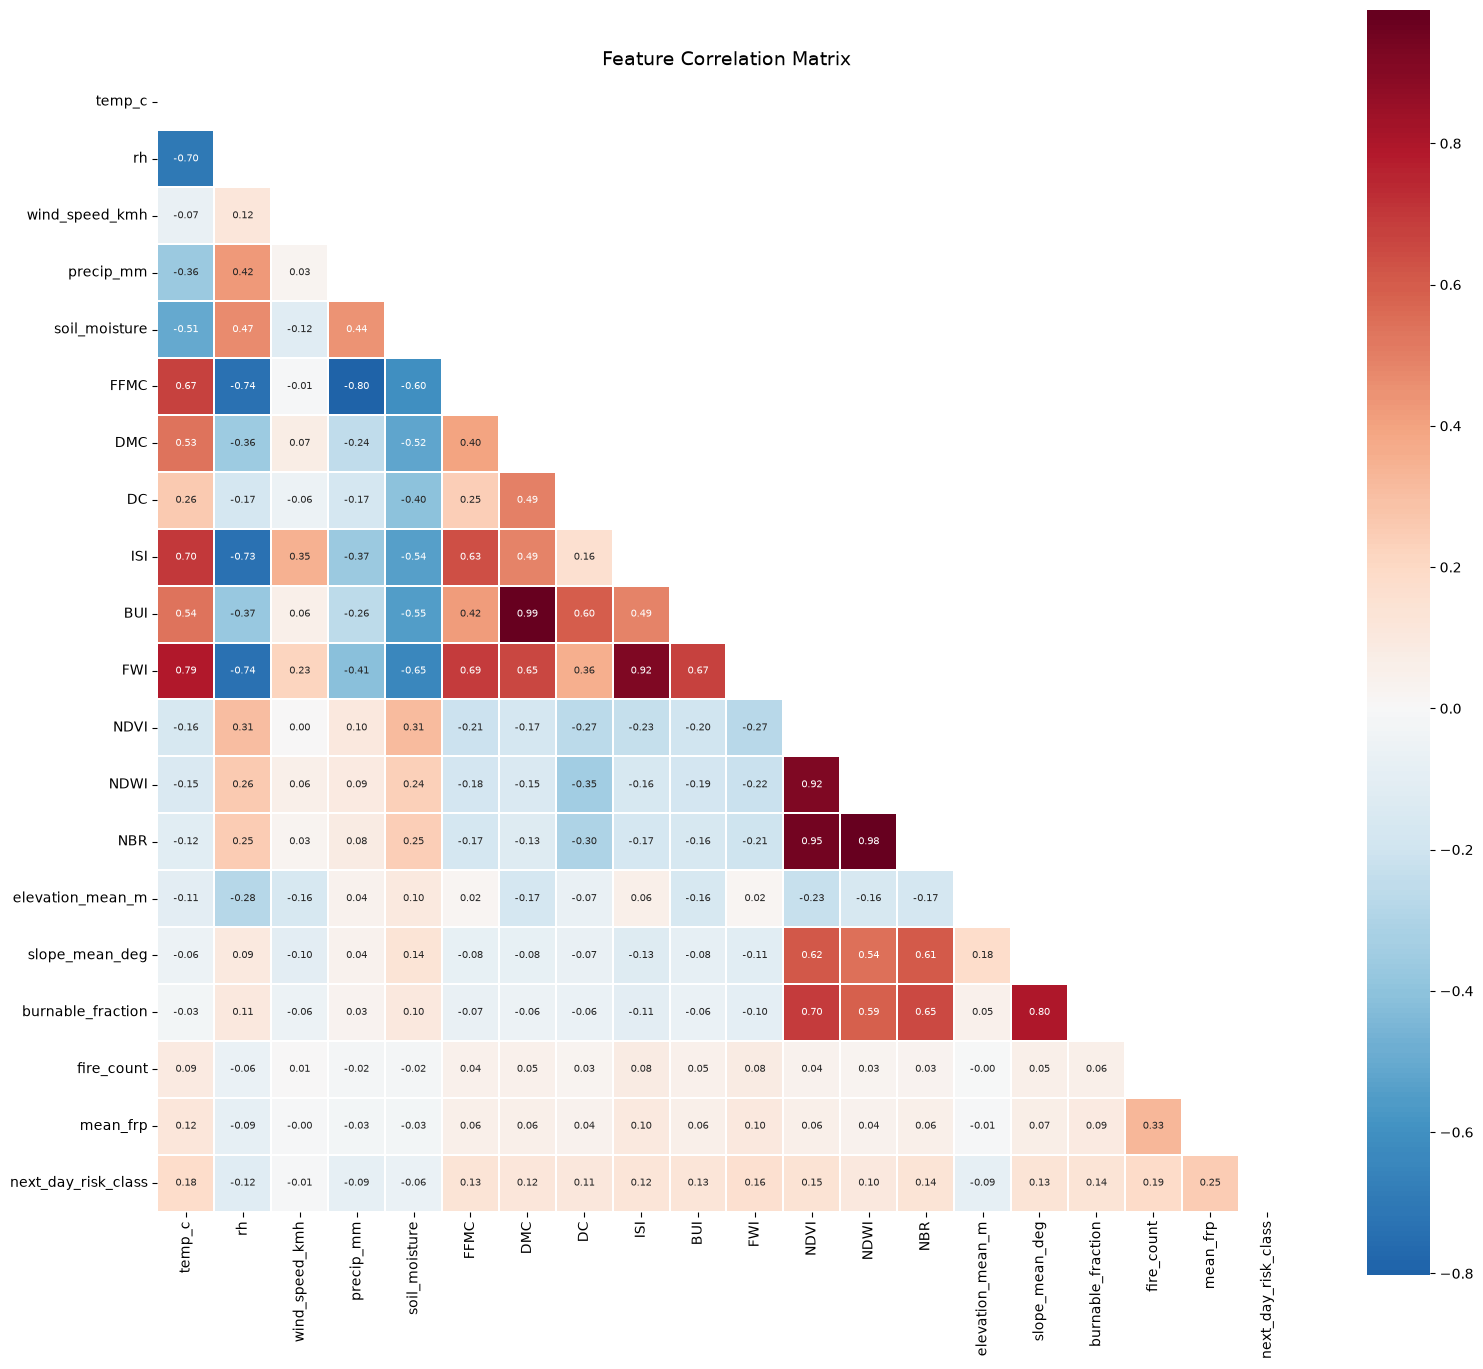


High correlation pairs (|r| > 0.7):
  DMC                    × BUI                    =  0.989
  NDWI                   × NBR                    =  0.981
  NDVI                   × NBR                    =  0.953
  NDVI                   × NDWI                   =  0.924
  ISI                    × FWI                    =  0.922
  precip_mm              × FFMC                   = -0.803
  slope_mean_deg         × burnable_fraction      =  0.797
  temp_c                 × FWI                    =  0.788
  rh                     × FFMC                   = -0.736
  rh                     × FWI                    = -0.735
  rh                     × ISI                    = -0.733
  temp_c                 × rh                     = -0.704

Total high-correlation pairs: 12
Note: Highly correlated FWI sub-indices may be candidates for
      dimensionality reduction in notebook 03.


In [9]:
corr_cols = [
    "temp_c", "rh", "wind_speed_kmh", "precip_mm", "soil_moisture",
    "FFMC", "DMC", "DC", "ISI", "BUI", "FWI",
    "NDVI", "NDWI", "NBR",
    "elevation_mean_m", "slope_mean_deg",
    "burnable_fraction", "fire_count", "mean_frp",
    "next_day_risk_class"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.3,
    annot_kws={"size": 7},
    ax=ax
)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/02_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag high multicollinearity pairs
print("\nHigh correlation pairs (|r| > 0.7):")
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            corr_pairs.append((corr_matrix.columns[i],
                               corr_matrix.columns[j], round(r, 3)))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in corr_pairs:
    print(f"  {a:<22} × {b:<22} = {r:>6.3f}")
print(f"\nTotal high-correlation pairs: {len(corr_pairs)}")
print("Note: Highly correlated FWI sub-indices may be candidates for")
print("      dimensionality reduction in notebook 03.")

#### Class seperation quality

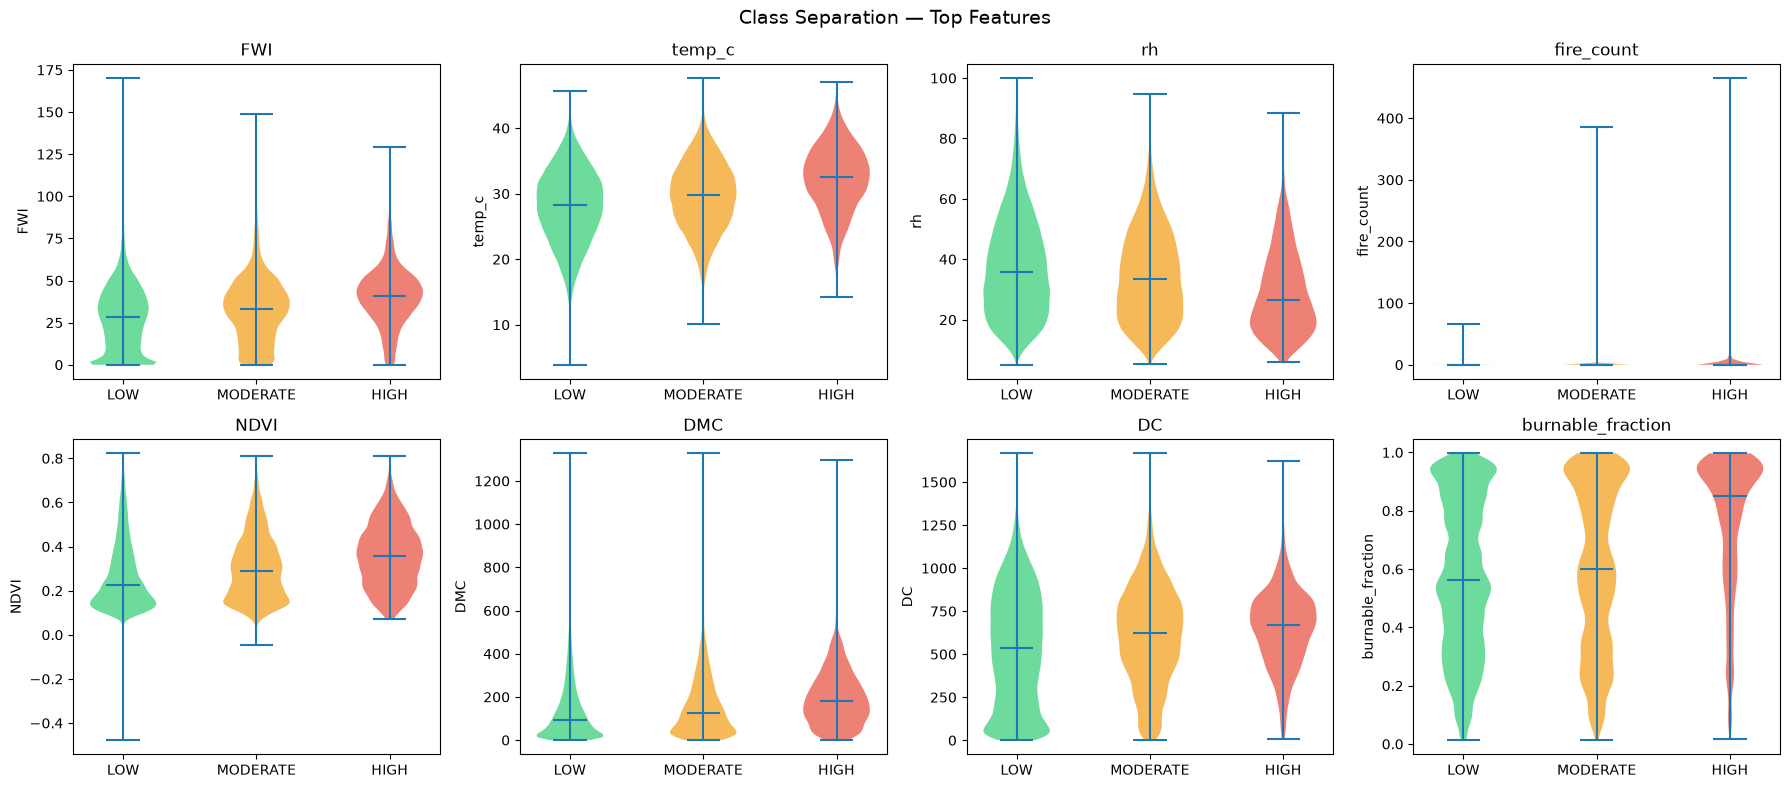


Class separation (mean HIGH − mean LOW):
  FWI                      :   +12.32  ↑ higher in fires
  temp_c                   :    +4.26  ↑ higher in fires
  rh                       :    -8.28  ↓ lower in fires
  fire_count               :    +3.95  ↑ higher in fires
  NDVI                     :    +0.09  ↑ higher in fires
  DMC                      :   +67.68  ↑ higher in fires
  DC                       :  +118.87  ↑ higher in fires
  burnable_fraction        :    +0.19  ↑ higher in fires


In [10]:
# How well do the top features separate the 3 classes?
top_features = ["FWI", "temp_c", "rh", "fire_count",
                "NDVI", "DMC", "DC", "burnable_fraction"]
top_features = [f for f in top_features if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    ax = axes[i]
    data = [df[df["next_day_risk_class"] == cls][col].dropna()
            for cls in [0, 1, 2]]
    vp = ax.violinplot(data, positions=[0, 1, 2], showmedians=True)
    for j, body in enumerate(vp["bodies"]):
        body.set_facecolor(RISK_COLORS[j])
        body.set_alpha(0.7)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([RISK_LABELS[i] for i in [0, 1, 2]])
    ax.set_title(col)
    ax.set_ylabel(col)

fig.suptitle("Class Separation — Top Features", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/02_class_separation.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify separation with mean difference between LOW and HIGH
print("\nClass separation (mean HIGH − mean LOW):")
for col in top_features:
    low  = df[df["next_day_risk_class"] == 0][col].mean()
    high = df[df["next_day_risk_class"] == 2][col].mean()
    diff = high - low
    direction = "↑ higher in fires" if diff > 0 else "↓ lower in fires"
    print(f"  {col:<25}: {diff:>+8.2f}  {direction}")

#### Wilaya level analysis

Wilaya fire statistics (sorted by positive rate):
       wilaya_name  rows  fire_days  positive_rate  mean_FWI  mean_burnable  mean_NDVI
       Constantine  2195       1003           45.7     27.42           0.41       0.24
             Jijel  4661       1980           42.5     26.22           0.91       0.55
            Annaba  2020        826           40.9     28.89           0.58       0.41
             Blida  4178       1708           40.9     27.79           0.66       0.39
            Skikda  6182       2350           38.0     25.23           0.79       0.48
              Oran  3990       1387           34.8     36.50           0.39       0.18
            Béjaïa  6826       2048           30.0     23.03           0.88       0.44
           El Tarf  3410        972           28.5     26.62           0.70       0.45
             Alger  3568        955           26.8     26.15           0.38       0.27
         Khenchela  2899        778           26.8     34.56           0.39     

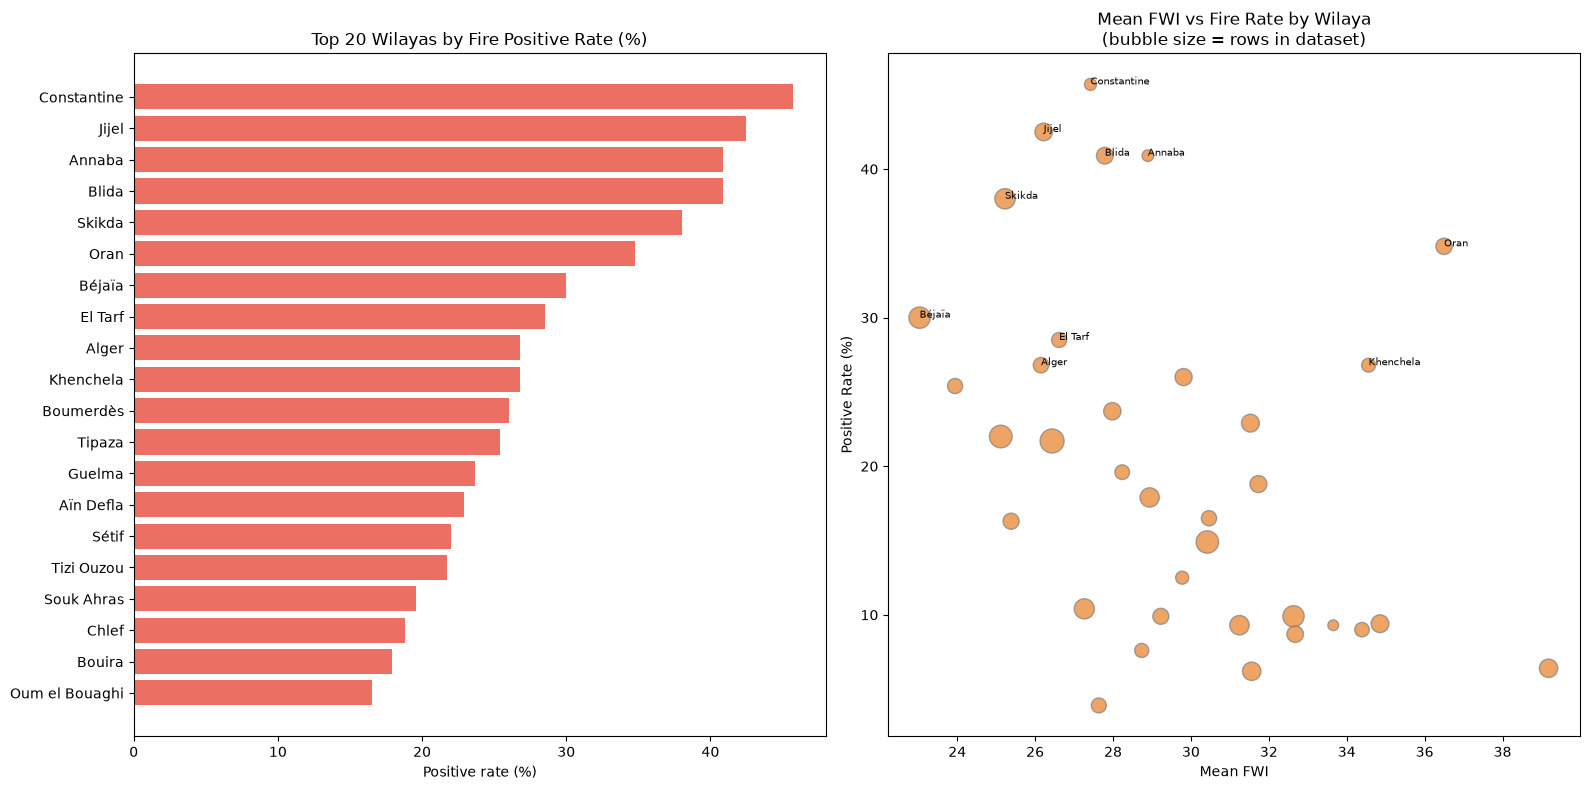

In [11]:
wilaya_stats = df.groupby("wilaya_name").agg(
    rows            =("date",               "count"),
    fire_days       =("next_day_risk_class", lambda x: (x > 0).sum()),
    positive_rate   =("next_day_risk_class", lambda x: round(100*(x > 0).mean(), 1)),
    mean_FWI        =("FWI",                "mean"),
    mean_burnable   =("burnable_fraction",  "mean"),
    mean_NDVI       =("NDVI",               "mean"),
).sort_values("positive_rate", ascending=False).reset_index()

print("Wilaya fire statistics (sorted by positive rate):")
print(wilaya_stats.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 wilayas by fire rate
top20 = wilaya_stats.head(20)
axes[0].barh(top20["wilaya_name"][::-1], top20["positive_rate"][::-1],
             color="#e74c3c", alpha=0.8)
axes[0].set_title("Top 20 Wilayas by Fire Positive Rate (%)")
axes[0].set_xlabel("Positive rate (%)")

# Mean FWI vs positive rate scatter
axes[1].scatter(wilaya_stats["mean_FWI"],
                wilaya_stats["positive_rate"],
                s=wilaya_stats["rows"] / wilaya_stats["rows"].max() * 300,
                alpha=0.7, color="#e67e22", edgecolors="gray")
for _, row in wilaya_stats.head(10).iterrows():
    axes[1].annotate(row["wilaya_name"],
                     (row["mean_FWI"], row["positive_rate"]),
                     fontsize=7, ha="left")
axes[1].set_xlabel("Mean FWI")
axes[1].set_ylabel("Positive Rate (%)")
axes[1].set_title("Mean FWI vs Fire Rate by Wilaya\n(bubble size = rows in dataset)")

plt.tight_layout()
plt.savefig("outputs/02_wilaya_stats.png", dpi=150, bbox_inches="tight")
plt.show()